# 滑动窗口

## 题目目录

- [3-6 无重复字符的最长子串](#lc-3)
- [209-4 长度最小的子数组](#lc-209)
- [713-5 乘积小于 K 的子数组](#lc-713)
- [438-8 找到字符串中所有字母异位词](#lc-438)


## 基础与模板


### 滑动窗口问题（同向双指针）

**使用滑动窗口算法一个重要的前提是单调性**(例如:数越多值越大,数越少值越小,如果存在负数的话这个条件就不再满足)

使用滑动窗口算法进入while循环后：

- **1.满足条件，先统计，再移动左指针使其逐渐不满足循环条件，这种一般是求解满足某个条件的最小值问题**
- **2.不满足条件，移动左指针使其满足条件后退出循环，在循环结束后进行相应的统计**

<a id="lc-3"></a>

## 3-6 无重复字符的最长子串


### 解题思路

注意当题目要求返回长度的时候，不一定需要创建一个变量来记录长度，使用左右指针同样可以做到

要特别注意索引在求解数组，字符串长度时的重要作用

这个题是从不满足条件到满足条件，因此从循环退出来后再去判断子串的最大长度


In [ ]:
from collections import Counter


class Solution(object):
    def lengthOfLongestSubstring(self, s):
        """
        :type s: str
        :rtype: int
        """
        hashtable = Counter()
        left = 0
        max_num = 0
        for right in range(len(s)):
            hashtable[s[right]] +=1
            while hashtable[s[right]] > 1:
                hashtable[s[left]]-=1
                left += 1
            max_num = max(max_num,right-left+1)
        return max_num

        Counter是Python标准库collections模块中的一个类，专门用于计数可哈希对象。它本质上是一个字典的子类，但专门
        为计数场景优化

        具体用法：
        1.自动完成所有计数工作
            text = "hello"
            count_counter = Counter(text)
            # 结果: Counter({'l':2, 'h':1, 'e':1, 'o':1})
        2.访问不存在键的行为：
            print(my_counter['b'])  # 返回 0，不会报错
        3.支持数学运算
        4.Counter的值获取：
            直接使用Counter[i]即可，而对于普通的字典类型，需要使用dict.get(i,0)来避免键不存在的情况


<a id="lc-209"></a>

## 209-4 长度最小的子数组


### 长度最小的子数组（这个题进入循环意味着满足条件，因此在满足条件的情况下去判断数组长度的最小值）

对于这个题而言，一个很关键的条件是数组全是正整数，满足单调性，即数越多值越大，数越少值越小，所以可以使用不定长滑动窗口算法

左指针的移动原理：当前的和大于target的时候，必须移动左指针暂停右指针的移动，因为如果继续移动右指针的话，根据单调性可知和肯定会大于target，但此时就不是最短的子数组了，因此需要移动左指针到不满足条件为止再继续移动右指针。


In [ ]:
class Solution(object):
    def minSubArrayLen(self, target, nums):
        """
        :type target: int
        :type nums: List[int]
        :rtype: int
        """
        left = 0
        ans = float('inf')
        s = 0
        for right,x in enumerate(nums):
            s+=x
            while s >= target:
                ans = min(ans,right-left+1)
                s -= nums[left]
                left += 1
        return ans if ans <= len(nums) else 0

<a id="lc-713"></a>

## 713-5 乘积小于 K 的子数组


### 乘积小于k的子数组之和

这个题也用到了单调性这个重要的概念，对于一个正数数组而言，数越多乘积越大，反之相反


In [ ]:
class Solution(object):
    def numSubarrayProductLessThanK(self, nums, k):
        if k<=1:
            return 0

        prod = 1
        ans = 0
        left = 0
        for right,x in enumerate(nums):
            prod *= x
            while prod >= k:#能进入循环意味着不满足条件，此时需要移动左指针，当从循环中退出时意味着从left开始到right结束的这一区域内所有元素的乘积都小于k，在这种情况下从区域内的任何一个元素出发到达右指针的乘积一定都小于k，因此数组个数有right - left + 1个。
                prod /= nums[left]
                left += 1

            ans += right - left +1
        return ans

<a id="lc-438"></a>

## 438-8 找到字符串中所有字母异位词


### 找到字符串中所有字母异位词（不定长滑动窗口）

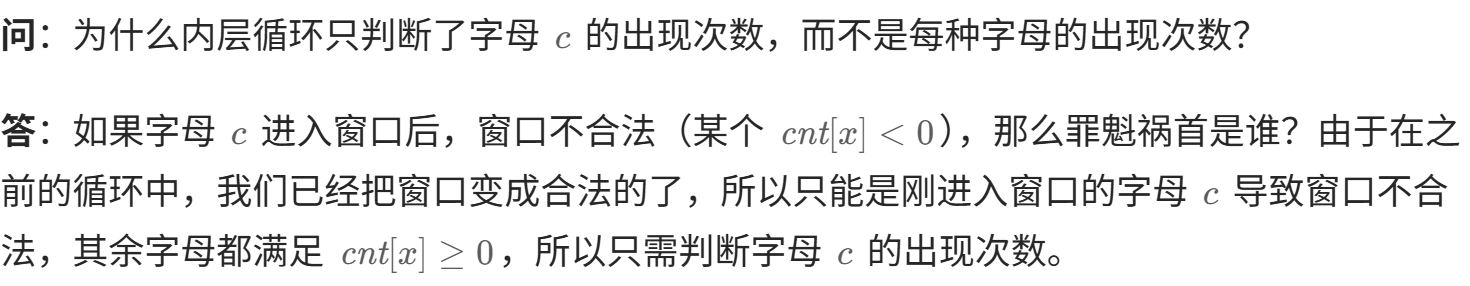


In [ ]:
class Solution:
    def findAnagrams(self, s: str, p: str) -> List[int]:
        cnt = Counter(p)  # 统计 p 的每种字母的出现次数
        ans = []

        left = 0
        for right, c in enumerate(s):
            cnt[c] -= 1  # 右端点字母进入窗口
            while cnt[c] < 0:  # 字母 c 太多了,含义为1:出现了在p中没有的字母，2:出现了在p中有的字母但是次数过多|
                cnt[s[left]] += 1  # 左端点字母离开窗口
                left += 1      
            #循环结束后能够保证 right端点字母c在窗口中出现的次数不超过p中出现的次数
            if right - left + 1 == len(p):  # t 和 p 的每种字母的出现次数都相同（证明见上）
                ans.append(left)  # t 左端点下标加入答案

        return ans